# Intro
We will use PyTorch to train a neural network for a regression task on the California Housing Dataset.
Our goal is to predict the values of the houses based on various predictive variables. Use the following
code to fetch the dataset and split it into a training and test dataset:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=302)
There are 15,480 training and 5,160 test examples with 8 predictive input features and 1 target
variable. Input features consist of the spatial locations of the districts that data is collected from

(latitude, longitude), demographic information in the districts (income, population, house occu-
pancy), and general information regarding the houses (number of rooms, number of bedrooms, age

of the house). Since these statistics are measured per district, the features correspond to averages or
medians across “block groups” (a geographical unit with a population of 600 to 3,000 people).
The input features (in X_train and X_test) are provided in the following order:
• MedInc : median income in block group
• HouseAge: median age of a house within a block
• AveRooms: average number of rooms per household
• AveBedrms: average number of bedrooms per household
• Population: block group population
• AveOccup: average number of household members
• Latitude: a measure of how far north a house is
• Longitude: a measure of how far west a house is
The target variable is the median house value for California districts, expressed in hundreds of
thousands of dollars ($100, 000).

# a)(3 pts) :
Get familiar with the dataset. Split X_train into an actual training set and a valida-
tion set. We will use this validation set during the model selection process. We will use the test set only to evaluate the final model (i.e., after model selection). Investigate the feature
distributions, include your plots in your report, and discuss your main observations.
You will have to normalize the features of this dataset. When you do that, make sure you
do not compute statistics using the validation or test set. Have a look at the hint below, and
explain in your report what is the difference when using fit_transform and transform.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
your_train_split = scaler.fit_transform(your_train_split)
your_val_split = scaler.transform(your_val_split)

Data Import

Shape before split: (20640, 8)
Original training shape: (15480, 8)
Training shape: (12384, 8)
Validation shape: (3096, 8)
Test shape: (5160, 8)


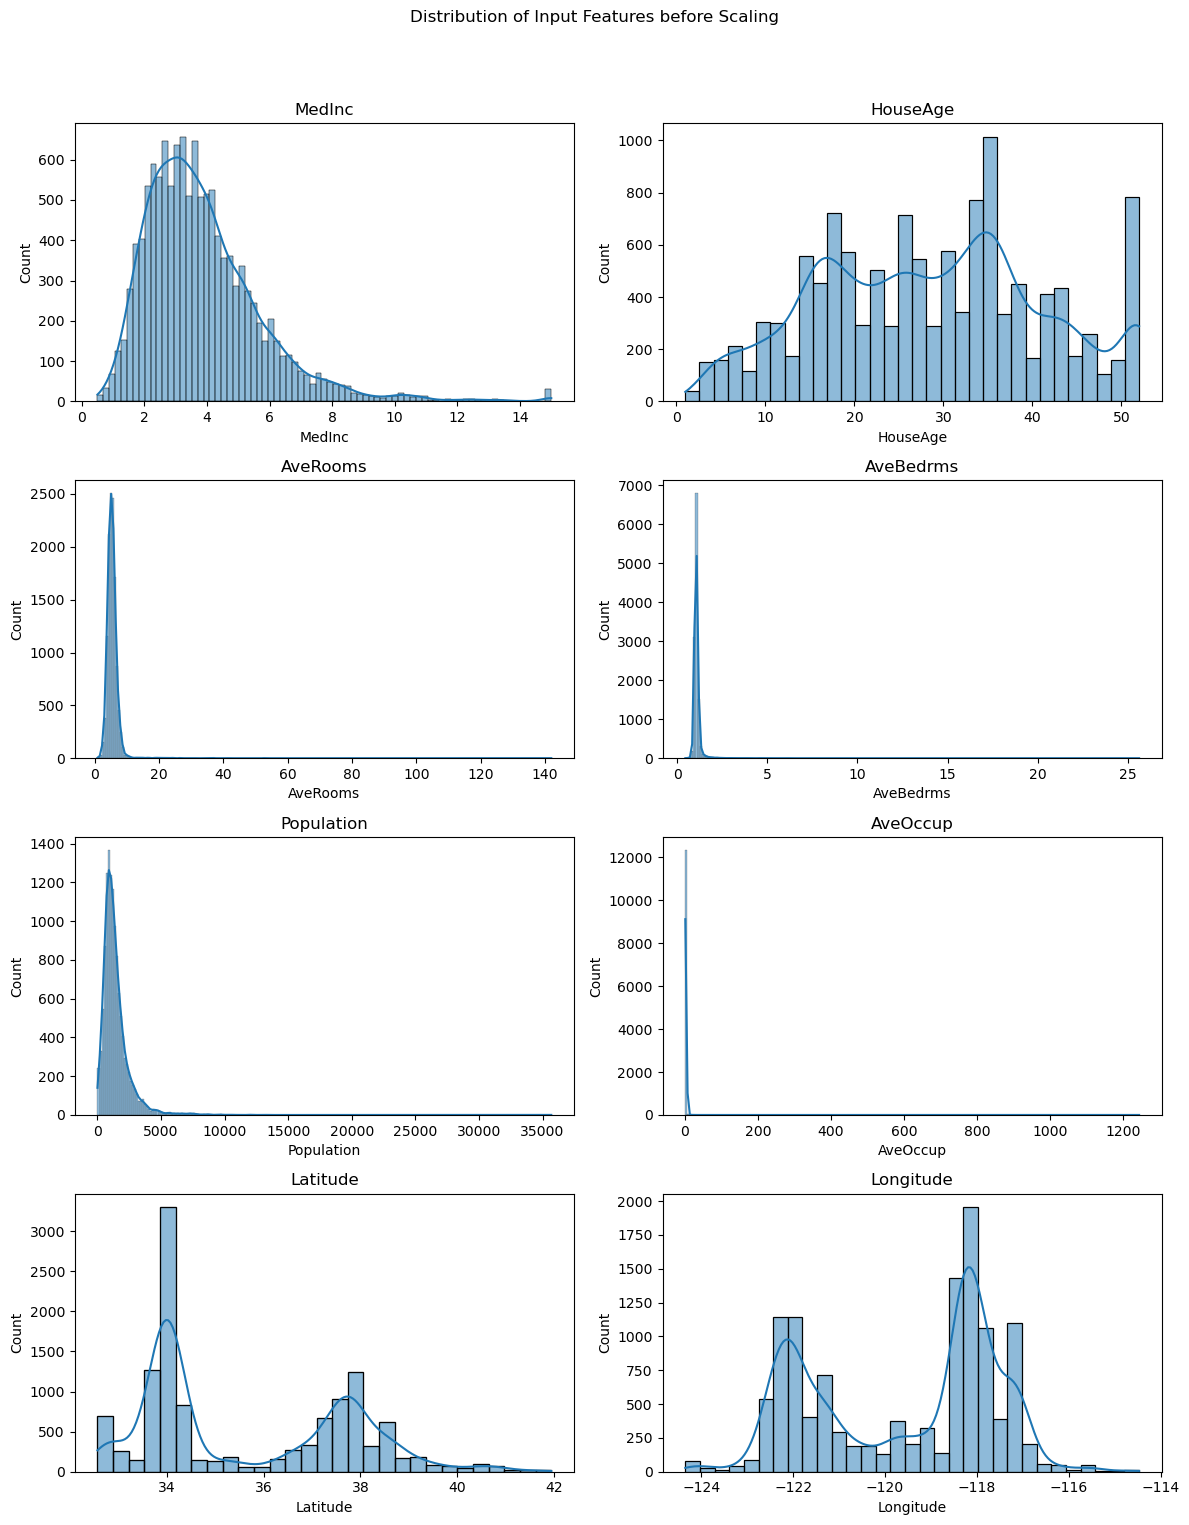

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)


X, y = fetch_california_housing(return_X_y=True)
X_train_org, X_test, y_train_org, y_test = train_test_split(X, y, test_size=0.25, random_state=302)

# names of features for the plots
feature_names = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]

# split into training and validation set -> 80% X_train, 20% X_val
X_train, X_val, y_train, y_val = train_test_split(X_train_org, y_train_org, test_size=0.2, random_state=302)

# check shapes
print(f"Shape before split: {X.shape}")
print(f"Original training shape: {X_train_org.shape}")
print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# feature scaling -> fit_transform to learn mü and standard deviation from the data,
# transform to use mü and standard deviation learned from training data
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

# create dataframe for easier plotting
df_train = pd.DataFrame(X_train, columns=feature_names)

# analyzing the data
#df_train.head()
#df_train.info()
#df_train.describe()

# creating template plots
fig, axes = plt.subplots(4, 2, figsize = (12, 16))
fig.suptitle("Distribution of Input Features before Scaling")

# flatten 2D Matrix in 1D array in order to be able to iterate
axes = axes.flatten()

# create plots
for i, col in enumerate(feature_names):
  sns.histplot(df_train[col], kde=True, ax=axes[i])
  axes[i].set_title(col)

# show plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# b) (6 pts) :
Design your feedforward neural network architecture for the regression task. Explain
your design choices for the output layer and the loss function that you will use during training.
Minimize the training loss using stochastic gradient descent (SGD) with a suitable mini-batch

size. Try at least 10 different configurations by varying numbers of hidden units and hid-
den layers. Provide a table where training and validation losses of various architectures and

optimization hyper-parameters (e.g., SGD learning rate, number of epochs) are compared.

Data Loader

In [8]:
# create class to convert numpy arrays into tensors
class HousingDataset(Dataset):
  def __init__(self, X, y):
    # convert to float tensors
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

# create datasets
train_dataset = HousingDataset(X_train_norm, y_train)
val_dataset = HousingDataset(X_val_norm, y_val)

# create DataLoaders
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)


Model Architecture

In [9]:
class RegressionNet(nn.Module):
  def __init__(self, hidden_layers):
    super(RegressionNet, self).__init__()

    layers = []
    input_dim = 8

    # dynamically creation of hidden layers
    for hidden_dim in hidden_layers:
      layers.append(nn.Linear(input_dim, hidden_dim))
      layers.append(nn.ReLU())
      input_dim = hidden_dim

    # add output layer
    layers.append(nn.Linear(input_dim, 1))

    # combine all layers into a sequential model
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

Training and Validation Loop

In [10]:
def train_model(model, train_loader, val_loader, learning_rate, num_epochs):
  criterion = nn.MSELoss()
  optimizer = optim.SGD(model.parameters(), lr=learning_rate)

  train_losses = []
  val_losses = []

  for epoch in range(num_epochs):
    model.train() # set model to train mode
    epoch_train_loss = 0.0
    for inputs, labels in train_loader:
      # forward pass
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      # backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      epoch_train_loss += loss.item() * inputs.size(0)

    # calculate average training loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # validation
    model.eval() # set model to evaluation mode
    epoch_val_loss = 0.0
    with torch.no_grad(): # no need to track gradients
      for inputs, labels in val_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        epoch_val_loss += loss.item() * inputs.size(0)

    # calculate avg validation loss
    avg_val_loss = epoch_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

  return train_losses, val_losses

Hyperparamater Tuning

In [11]:
configurations = [
    # arch (hidden layers), LR
    ([32], 0.01),
    ([32], 0.001),
    ([64], 0.01),
    ([64], 0.001),
    ([128], 0.001),
    ([64, 32], 0.01),
    ([64, 32], 0.001),
    ([128, 64], 0.001),
    ([128, 64, 32], 0.001),
    ([256, 128], 0.001)
]

NUM_EPOCHS_TUNING = 50
results = []

print("--- Hyperparameter Tuning ---")

for config in configurations:
  arch, lr = config
  model = RegressionNet(hidden_layers=arch)

  train_losses, val_losses = train_model(
      model, train_loader, val_loader, learning_rate=lr, num_epochs=NUM_EPOCHS_TUNING
  )

  final_train_loss = train_losses[-1]
  final_val_loss = val_losses[-1]

  results.append({
      "Architecture": str(arch),
      "Learning Rate": lr,
      "Epochs": NUM_EPOCHS_TUNING,
      "Final Train Loss": final_train_loss,
      "Final Validation Loss": final_val_loss
  })

  print(f"Config: {str(arch)}, LR: {lr} Train Loss: {final_train_loss:.4f}, Val Loss: {final_val_loss:.4f}")

print("--- Tuning Complete ---")

# display results in a table
results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False, floatfmt=".4f"))



--- Hyperparameter Tuning ---
Config: [32], LR: 0.01 Train Loss: 0.3515, Val Loss: 0.3912
Config: [32], LR: 0.001 Train Loss: 0.4611, Val Loss: 0.5090
Config: [64], LR: 0.01 Train Loss: 0.3367, Val Loss: 0.3783
Config: [64], LR: 0.001 Train Loss: 0.4656, Val Loss: 0.5127
Config: [128], LR: 0.001 Train Loss: 0.4526, Val Loss: 0.5011
Config: [64, 32], LR: 0.01 Train Loss: 0.3046, Val Loss: 0.3396
Config: [64, 32], LR: 0.001 Train Loss: 0.4306, Val Loss: 0.4730
Config: [128, 64], LR: 0.001 Train Loss: 0.4224, Val Loss: 0.4606
Config: [128, 64, 32], LR: 0.001 Train Loss: 0.4169, Val Loss: 0.4539
Config: [256, 128], LR: 0.001 Train Loss: 0.3993, Val Loss: 0.4368
--- Tuning Complete ---
| Architecture   |   Learning Rate |   Epochs |   Final Train Loss |   Final Validation Loss |
|:---------------|----------------:|---------:|-------------------:|------------------------:|
| [32]           |          0.0100 |       50 |             0.3515 |                  0.3912 |
| [32]           |       

# c) (2 pts) :
Clearly summarize your final model once your architecture choices are fixed. Provide a
plot where the evolution of the training and validation loss during training are shown throughout
iterations. Perform a final training with this model on the whole training set (i.e., combine the
proper training set and the validation set). Report and comment on the final test loss. Provide
a scatter plot in which you compare model predictions (x-axis) with their ground truth values
(y-axis) on the test set.

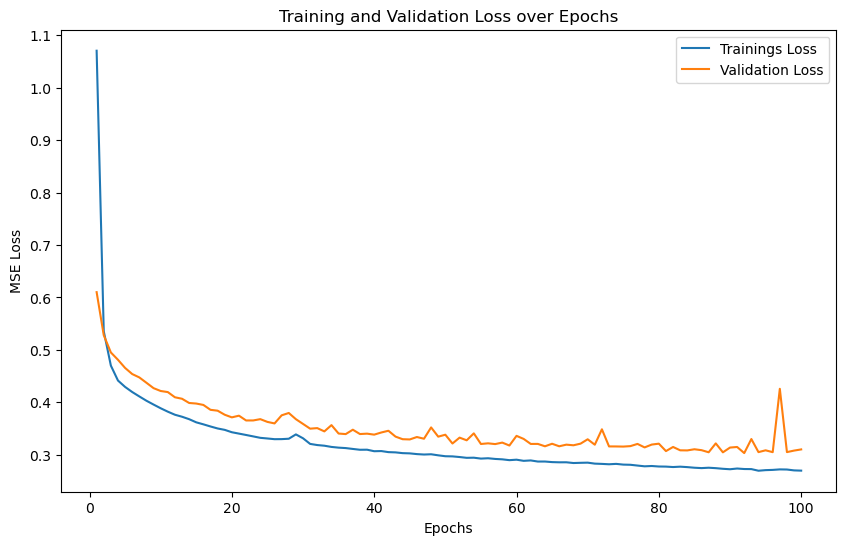

In [12]:
# plotting the best models learning curve
final_arch = [64, 32]
final_lr = 0.01
final_epochs = 100

best_model = RegressionNet(final_arch)
train_losses, val_losses = train_model(
    best_model, train_loader, val_loader,
    learning_rate = final_lr,
    num_epochs = final_epochs
)

plt.figure(figsize=(10, 6))
plt.plot(range(1, final_epochs +1), train_losses, label="Trainings Loss")
plt.plot(range(1, final_epochs +1), val_losses, label="Validation Loss")
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Final Training and Test Set Evaluation

In [13]:
# Combine train and val sets
X_train_full = np.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

print(f"Shape of X_train_full: {X_train_full.shape}")

# Scaler
final_scaler = StandardScaler()
X_train_full_norm = final_scaler.fit_transform(X_train_full)
X_test_final_norm = final_scaler.transform(X_test)

# final dataset and loaders
final_train_dataset = HousingDataset(X_train_full_norm, y_train_full)
final_test_dataset = HousingDataset(X_test_final_norm, y_test)

final_train_loader = DataLoader(final_train_dataset, batch_size=batch_size, shuffle=True)
final_test_loader = DataLoader(final_test_dataset, batch_size=batch_size, shuffle=False)

# train final model
final_model = RegressionNet(final_arch)
criterion = nn.MSELoss()
optimizer = optim.SGD(final_model.parameters(), lr=final_lr)

for epoch in range(final_epochs):
  final_model.train()
  for inputs, labels in final_train_loader:
    outputs = final_model(inputs)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Final Model Training Complete")


Shape of X_train_full: (15480, 8)
Final Model Training Complete


Evaluate trained model on the test set

In [14]:
final_model.eval()
test_loss = 0.0
all_predictions = []
all_ground_truth = []

with torch.no_grad():
  for inputs, labels in final_test_loader:
    outputs = final_model(inputs)
    loss = criterion(outputs, labels)
    test_loss += loss.item() * inputs.size(0)

    # store for scatter plot
    all_predictions.extend(outputs.numpy())
    all_ground_truth.extend(labels.numpy())

final_test_loss = test_loss / len(final_test_loader.dataset)

print(f"Final Test Loss: {final_test_loss:.4f}")

# convert lists to numpy arrays
all_predictions = np.array(all_predictions).flatten()
all_ground_truth = np.array(all_ground_truth).flatten()

# scatter plot

Final Test Loss: 0.2893


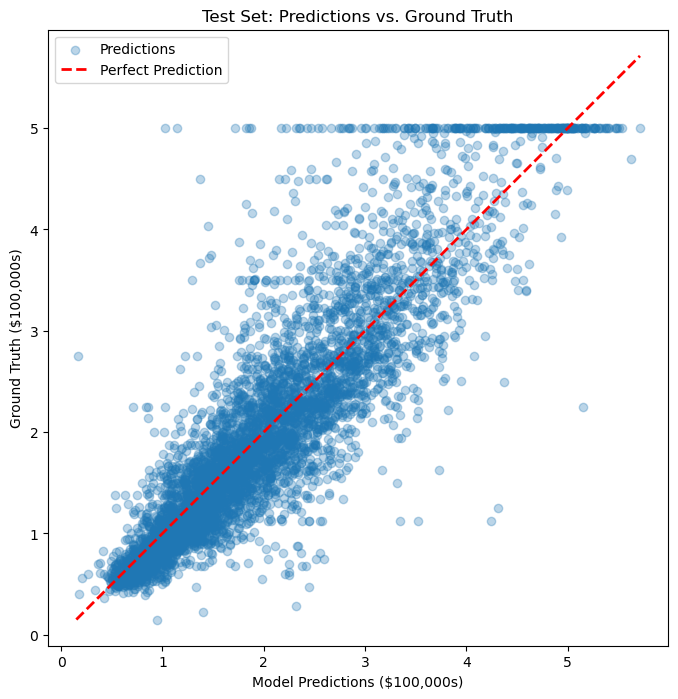

In [15]:
# Generate scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(all_predictions, all_ground_truth, alpha=0.3, label='Predictions')
# Add the y=x line (perfect prediction)
min_val = min(min(all_predictions), min(all_ground_truth))
max_val = max(max(all_predictions), max(all_ground_truth))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Test Set: Predictions vs. Ground Truth')
plt.xlabel('Model Predictions ($100,000s)')
plt.ylabel('Ground Truth ($100,000s)')
plt.legend()
plt.axis('equal') # Ensure x and y axes have the same scale
plt.show()

# d) (4 pts) :
Now assume that we want to use a similar architecture for the binary classification
problem of determining if the median house value is below or over $200, 000. Explain which
parts of the architecture design and the training pipeline you would have to change, and which
test set evaluation metrics should be investigated in this case. Explain in detail the reasons for
these differences.
Implement these changes to the final architecture and the training pipeline you had in Task
(c), and train a single model for this binary classification task using the whole training set.
Note that you will also need to redefine your target variables by executing the lines:
y_train[y_train < 2], y_test[y_test < 2] = 0, 0
y_train[y_train >= 2], y_test[y_test >= 2] = 1, 1
Evaluate your model on the test set, report and comment on its performance.

In [16]:
# Make copies to not overwrite regression targets
y_train_class = y_train_full.copy()
y_test_class = y_test.copy()

# Apply the threshold
y_train_class[y_train_class < 2] = 0
y_train_class[y_train_class >= 2] = 1

y_test_class[y_test_class < 2] = 0
y_test_class[y_test_class >= 2] = 1

# Check class balance
print(f"Training set Class 1 (>= $200k): {np.mean(y_train_class) * 100:.2f}%")
print(f"Test set Class 1 (>= $200k): {np.mean(y_test_class) * 100:.2f}%")

Training set Class 1 (>= $200k): 42.29%
Test set Class 1 (>= $200k): 42.79%


Classification model training complete.

--- Classification Model Test Results ---
Accuracy:  86.38%
Precision: 0.8521
Recall:    0.8247
F1-Score:  0.8382

Confusion Matrix:
[[2636  316]
 [ 387 1821]]


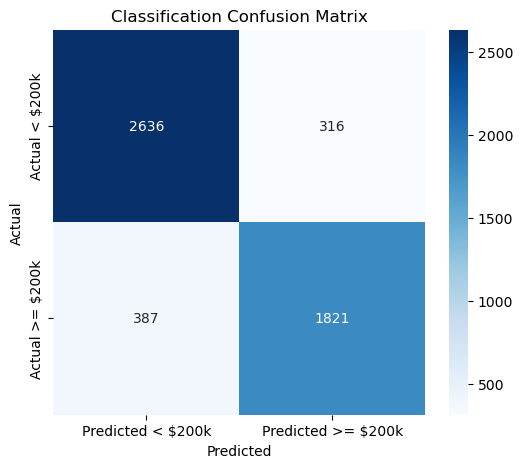

In [17]:
# Create new Datasets for classification
# Note: y_train_class is already on the full training set
class_train_dataset = HousingDataset(X_train_full_norm, y_train_class)
class_test_dataset = HousingDataset(X_test_final_norm, y_test_class)

class_train_loader = DataLoader(class_train_dataset, batch_size=batch_size, shuffle=True)
class_test_loader = DataLoader(class_test_dataset, batch_size=batch_size, shuffle=False)

# Use the same architecture
class_model = RegressionNet(final_arch)

# Use BCEWithLogitsLoss and SGD
criterion_class = nn.BCEWithLogitsLoss()
optimizer_class = optim.SGD(class_model.parameters(), lr=final_lr)

# Train the classification model
for epoch in range(final_epochs):
    class_model.train()
    for inputs, labels in class_train_loader:
        # 'labels' is already (batch_size, 1) and float, from our Dataset class

        # Forward pass
        logits = class_model(inputs) # Output is raw logits
        loss = criterion_class(logits, labels)

        # Backward pass and optimization
        optimizer_class.zero_grad()
        loss.backward()
        optimizer_class.step()

print("Classification model training complete.")

# --- Evaluate the classification model ---
class_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in class_test_loader:
        logits = class_model(inputs)

        # Convert logits to probabilities -> predictions
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int() # Threshold at 0.5

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Flatten lists
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

# Calculate and report metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n--- Classification Model Test Results ---")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted < $200k', 'Predicted >= $200k'],
            yticklabels=['Actual < $200k', 'Actual >= $200k'])
plt.title('Classification Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()